# Rubin Alert Cutout Viewer

Load and display FITS cutout images extracted by `rubin-alert2json`.

In [1]:
import glob
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

OUTPUT_DIR = "../output"

In [2]:
# Load all alert JSON files
json_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.json")))
alerts = {}
for jf in json_files:
    with open(jf) as f:
        alert = json.load(f)
    alert_id = str(alert["diaSourceId"])
    alerts[alert_id] = alert

print(f"Loaded {len(alerts)} alerts")
for aid, a in alerts.items():
    src = a["diaSource"]
    print(f"  {aid}  RA={src['ra']:.4f}  Dec={src['dec']:.4f}  psfFlux={src['psfFlux']:.1f} nJy")

Loaded 8 alerts
  170239611403501616  RA=148.6559  Dec=1.6710  psfFlux=13277.7 nJy
  170239611403501617  RA=148.6622  Dec=1.6653  psfFlux=3364.2 nJy
  170239611403501631  RA=148.6820  Dec=1.7137  psfFlux=1813.2 nJy
  170239611403501655  RA=148.7268  Dec=1.7166  psfFlux=3357.3 nJy
  170239611403501672  RA=148.7553  Dec=1.7129  psfFlux=3013.6 nJy
  170239611403501681  RA=148.5377  Dec=1.7266  psfFlux=-5008.6 nJy
  170239611403501714  RA=148.6630  Dec=1.7858  psfFlux=-35241.3 nJy
  170239611403501719  RA=148.6408  Dec=1.8757  psfFlux=-5974.6 nJy


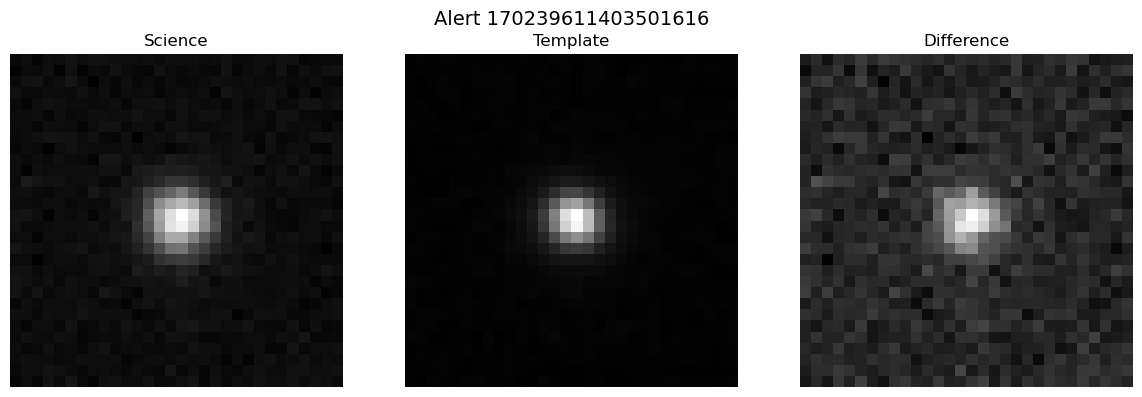

In [3]:
# Display all three cutouts for the first alert
alert_id = list(alerts.keys())[0]
alert = alerts[alert_id]
cutout_names = ["cutoutScience", "cutoutTemplate", "cutoutDifference"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, cutout_names):
    fits_file = alert.get(name)
    if fits_file is None:
        ax.set_title(f"{name}\n(not available)")
        ax.axis("off")
        continue
    filepath = os.path.join(OUTPUT_DIR, fits_file)
    data = fits.getdata(filepath)
    ax.imshow(data, origin="lower", cmap="gray")
    ax.set_title(name.replace("cutout", ""))
    ax.axis("off")
fig.suptitle(f"Alert {alert_id}", fontsize=14)
plt.tight_layout()
plt.show()

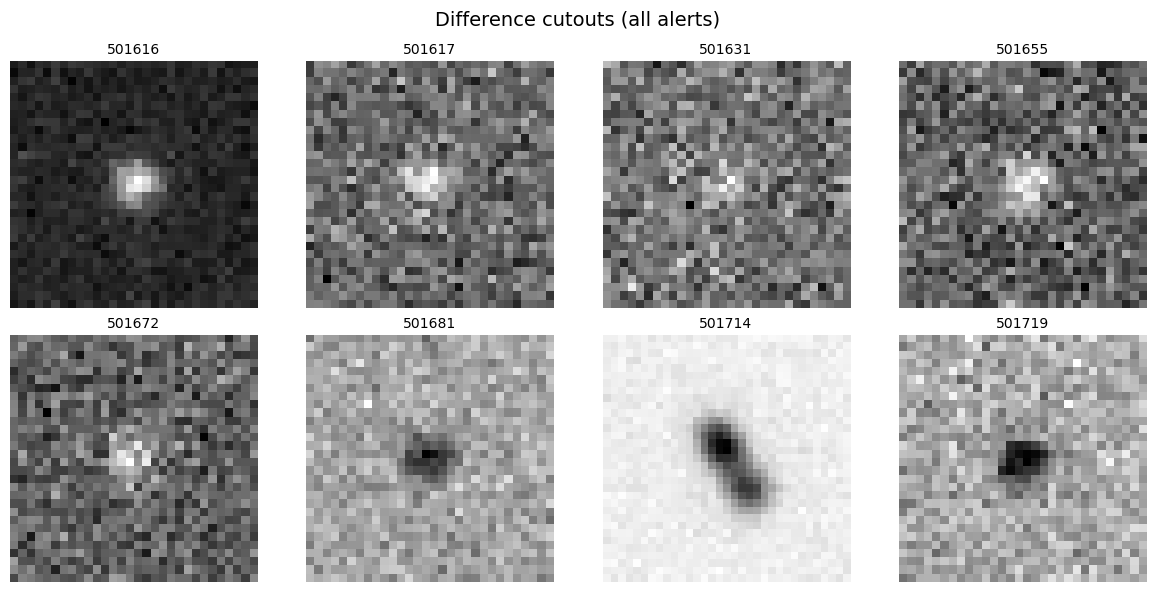

In [4]:
# Grid of difference cutouts for all alerts
alert_ids = list(alerts.keys())
n = len(alert_ids)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.atleast_2d(axes)
for i, aid in enumerate(alert_ids):
    ax = axes[i // ncols, i % ncols]
    fits_file = alerts[aid].get("cutoutDifference")
    if fits_file is not None:
        data = fits.getdata(os.path.join(OUTPUT_DIR, fits_file))
        ax.imshow(data, origin="lower", cmap="gray")
    ax.set_title(aid[-6:], fontsize=10)
    ax.axis("off")

# Hide unused axes
for i in range(n, nrows * ncols):
    axes[i // ncols, i % ncols].axis("off")

fig.suptitle("Difference cutouts (all alerts)", fontsize=14)
plt.tight_layout()
plt.show()